# Crumblr — Compositional Differential Abundance

Uses **crumblr** (CLR + dream mixed-effects) as an alternative to scCODA.  
Same dataset, same tissue × annotation-level grid.

**Setup (one-time):** `bash /home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/setup_env.sh`  
**Kernel:** any env with `scanpy` + `pandas` (e.g. `python3`/`.venv`) — crumblr runs in its own venv via subprocess.

In [8]:
%load_ext autoreload
%autoreload 2

import os, subprocess, json, glob
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image
import numpy as np

# ── Paths ─────────────────────────────────────────────────────────────────────
ADATA          = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/SN/SN_combined_QC_mmc_ct-cured.h5ad"

TISSUE         =  ADATA.split("/")[-2]
SAVE_FOLDER    = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/{TISSUE}"
CRUMBLR_SCRIPT = "/home/gdallagl/myworkdir/XDP/data/crumblr/crumblr/run_workflow.py"
MAPPING_JSON   = "/home/gdallagl/myworkdir/XDP/utils/STR_cell_types_annotation/group_level_mmc_mapping.json"

# ── Study design ──────────────────────────────────────────────────────────────
SAMPLE_COL     = "donor_id"
CONTRAST_COL   = "condition"
CONTRAST_REF   = "Control"
CONTRAST_STIM  = "XDP"
FIXED_EFFECTS  = ["sex", "cohort", "age_of_death"]  # fixed covariates
RANDOM_EFFECTS = []  # donor_id can't be a random effect: 1 sample per donor after aggregation → use lmFit

os.makedirs(SAVE_FOLDER, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
adata = sc.read_h5ad(ADATA, backed="r")
print(adata)
print("Cell counts by tissue:", adata.obs["tissue"].value_counts().to_dict())

AnnData object with n_obs × n_vars = 125635 × 38601 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/SN/SN_combined_QC_mmc_ct-cured.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_m

In [10]:
# Remove bad cell types 
adata = adata[~adata.obs["ct_for_deg"].str.startswith("-")].to_memory().copy()

# Remove cell types wiht too few samples
cell_type_counts = adata.obs["ct_for_deg"].value_counts()
cell_types_to_keep = cell_type_counts[cell_type_counts >= 10].index
adata = adata[adata.obs["ct_for_deg"].isin(cell_types_to_keep)].copy()

## Helper functions

In [11]:
import sys
sys.path.insert(0, "/home/gdallagl/myworkdir/XDP/data/crumblr")  # directory, not file path
from plot_crumblr import plot_all as _plot_all

# Columns that every CSV needs (cell-type col is added separately per run)
META_COLS = [SAMPLE_COL, CONTRAST_COL, *FIXED_EFFECTS]

# Subprocess env: override the Jupyter inline backend (invalid outside Jupyter)
_SUBPROCESS_ENV = {**os.environ, "MPLBACKEND": "Agg"}


def drop_bad_samples(adata):
    """Remove donors with any missing covariate."""
    bad = {s for col in META_COLS
              for s in adata.obs[adata.obs[col].isna()][SAMPLE_COL].unique()}
    return adata[~adata.obs[SAMPLE_COL].isin(bad)]

def filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3):
    """Remove cell types present in too few donors (would break lmFit)."""
    counts = (
        adata.obs[[ct_col, SAMPLE_COL]]
        .groupby([ct_col, SAMPLE_COL])
        .size()
        .reset_index(name="n_cells")
    )
    donor_counts = (
        counts[counts["n_cells"] >= min_cells_per_sample]
        .groupby(ct_col)[SAMPLE_COL]
        .nunique()
    )
    keep = donor_counts[donor_counts >= min_samples].index
    removed = set(adata.obs[ct_col].unique()) - set(keep)
    if removed:
        print(f"  removing {len(removed)} rare type(s): {sorted(removed)}")
    return adata[adata.obs[ct_col].isin(keep)]

def run_crumblr(adata_sub, ct_col, output_dir, label="", show=False):
    """
    Export a cell-level CSV, call run_workflow.py, then plot results with plot_crumblr.py.
    All CSVs + original PDFs/PNGs are saved to output_dir by run_workflow.py.
    Custom plots saved to output_dir/images/ by plot_crumblr.py.
    Returns the results DataFrame (one row per cell type × coefficient).
    """
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, "cells.csv")

    # Write cell-level CSV (one row per cell, columns = ct + metadata)
    df = adata_sub.obs[[ct_col, *META_COLS]].dropna().copy()
    df[ct_col] = df[ct_col].astype(str)
    df.to_csv(csv_path, index=False)

    cmd = [
        "python", CRUMBLR_SCRIPT,
        "--csv",            csv_path,
        "--proportion-col", ct_col,
        "--sample-col",     SAMPLE_COL,   # one sample per donor → same as donor-col
        "--donor-col",      SAMPLE_COL,
        "--contrast",       CONTRAST_COL,
        "--ref-level",      CONTRAST_REF,
        "--output-dir",     output_dir,
        "--fixed-effects",  *FIXED_EFFECTS,
        "--random-effects", *RANDOM_EFFECTS,
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, env=_SUBPROCESS_ENV)
    print(result.stdout[-2000:])  # trim output to avoid flooding the notebook
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError(f"crumblr failed → {output_dir}")

    # Custom plots: use actual cell type names, no internal class mapping
    _plot_all(output_dir, contrast_col=CONTRAST_COL, contrast_stim=CONTRAST_STIM, label=label, show=show)

    return pd.read_csv(os.path.join(output_dir, "crumblr_results.csv"))


def run_crumblr_grid(adata, annotation_levels, out_dir, show=False):
    """Run crumblr for every annotation level on the tissue adata."""

    # remove samples with nan in some metadata
    adata = drop_bad_samples(adata).to_memory().copy()

    df_list = []
    for ct_col in annotation_levels:
        
        label = f"{TISSUE} | {ct_col}"
        print(f"\n{'='*60}\n{label}")
        #print(adata.obs[ct_col].value_counts())

        # remove ct with too few cells or samples
        adata_ct = filter_rare_celltypes(adata, ct_col, min_samples=5, min_cells_per_sample=3)

        ct_out_dir = f"{out_dir}/{ct_col}"
        df = run_crumblr(adata_ct, ct_col, ct_out_dir, label=label, show=show)
        df["tissue"]     = TISSUE
        df["annotation"] = ct_col
        df_list.append(df)

    merged = pd.concat(df_list, ignore_index=True)
    merged.to_csv(f"{out_dir}/merged_results.csv", index=False)
    return merged

## All cells

using all cells, for each annotation granularity level.

In [5]:
if TISSUE == "Striatum":
    
    col_zoning = []

    for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
        
        print(f"\n#################\n{col_zones}\n##############\n")

        for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():
            
            # Get the group names of th e cell types that use this cell type for zoning
            group_name_ct_that_use_this_ct_for_zoning = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
            print(f"\nUsing {ct_used_for_zoning} to assign zones to {group_name_ct_that_use_this_ct_for_zoning}")

            if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
                continue

            # Create labels
                # zones for the cell types that use this ct for zoning
                # "Other" for all other cell types
                # ATTENTION: some cells are "this ct for zoning", but received Nan as zone assignement
            zone_col = f"{col_zones}_assigned_by_{ct_used_for_zoning}"
            print(zone_col)
            mask = adata.obs["Group_name"].isin(group_name_ct_that_use_this_ct_for_zoning) # mask of cells that received the ct for zoning
            zone_vals = adata.obs[col_zones].astype(str) # zone values

            adata.obs[zone_col] = adata.obs["Group_name"].astype(str)  # default: actual group name
            valid_mask = mask & adata.obs[col_zones].notna() # only cells that have a zone 
            adata.obs.loc[valid_mask, zone_col] = zone_vals[valid_mask] + "_" + ct_used_for_zoning
            zones_names = adata.obs.loc[valid_mask, zone_col].unique().tolist()

            # Label cells in the group but without a zone assignment
            unzoned_mask = mask & adata.obs[col_zones].isna()
            unzoned_col = "unzoned_" + ct_used_for_zoning
            adata.obs.loc[unzoned_mask, zone_col] = unzoned_col
            
            print("cells ")

            col_zoning.append(zone_col)

            #print(adata.obs[zone_col].value_counts())
            # sc.pl.umap(adata, color=zone_col, groups=group_name_ct_that_use_this_ct_for_zoning, size=10, title=zone_col)
            # sc.pl.umap(adata, color=zone_col, groups=zones_names, size=10, title=zone_col)
            sc.pl.umap(adata, color=zone_col, groups=[*zones_names, *group_name_ct_that_use_this_ct_for_zoning, unzoned_col], size=10, title=zone_col)

        #     break
        # break
        

In [12]:
LEVELS_ALL = ["ct_for_deg"]

if TISSUE == "Striatum":
    LEVELS_ALL = LEVELS_ALL + col_zoning # Only Striatum has zones
    LEVELS_ALL = LEVELS_ALL + ["Class_name", "Subclass_name", "Group_name"] # only stritum has atals for all ct

print("Annotation levels:", LEVELS_ALL)

df_all = run_crumblr_grid(adata, annotation_levels=LEVELS_ALL, out_dir = f"{SAVE_FOLDER}/all_cells", show=False)
df_all.head()

Annotation levels: ['ct_for_deg']

SN | ct_for_deg
  removing 9 rare type(s): ['Bcell', 'Exc_5HT', 'Exc_CYP2J2_CRH', 'Exc_PAX5_F13A1', 'Exc_POSTN', 'Exc_SALL1_TDO2', 'Inh_EGFLAM', 'Inh_EXPH5_TFAP2B', 'Inh_PPP1R1B_DRD3']


/tmp/ipykernel_1175591/2488500834.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_1175591/2488500834.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/SN/all_cells/ct_for_deg/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 4 sample(s) with < 100 cells: ['SCF_21_029', 'SCF_21_034', 'SCF_22_049CCF', 'SCF_23_074CF']
  Contrast 'condition' detected as categorical.
  Samples: 36  |  Cell types: 28
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 36  |  Cell types: 28
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─────────────────────────────────────────────────
── Extracting results ──────────────────────────────────────────────────
  Test coefficients: conditionX

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient,tissue,annotation
0,-0.222419,3.630178,-1.280669,0.208996,0.390125,-4.812287,Astrocyte,conditionXDP,SN,ct_for_deg
1,-0.120530,-0.438434,-0.440210,0.662577,0.773006,-5.677881,Da_CALB1_CALCR_CRYM,conditionXDP,SN,ct_for_deg
2,0.284579,-1.009855,1.322489,0.194851,0.390125,-4.972556,Da_CALB1_TMEM200A,conditionXDP,SN,ct_for_deg
3,-0.487094,0.042022,-1.281045,0.208865,0.390125,-5.001068,Da_SOX6_AGTR1_EYA4,conditionXDP,SN,ct_for_deg
4,0.062285,-1.112869,0.193717,0.847553,0.878944,-5.662676,Da_SOX6_GFRA2_PART1,conditionXDP,SN,ct_for_deg


## Neurons only

Exclude non-neuronal cells. Groups not in the JSON mapping are labelled `NON_MSN` (the reference category).

In [13]:
#filter onyl neruons
if TISSUE == "Striatum":
    adata_n = adata[adata.obs["Neighborhood_name"] != "Nonneuron"].to_memory().copy()
if (TISSUE == "DFC") | (TISSUE == "SN"):
    adata_n = adata[adata.obs["is_neuron"]].to_memory().copy()

In [17]:
LEVELS_NEURONS = ["ct_for_deg"]

if TISSUE == "Striatum":
    LEVELS_NEURONS = LEVELS_NEURONS + ["Class_name", "Subclass_name", "Group_name"] # only stritum has atals for all ct
elif TISSUE == "DFC":
    LEVELS_NEURONS = LEVELS_NEURONS + ["DFC_Group_name", "DFC_Subclass_name"] # only DFC has atals for neurons at class and subclass level
elif TISSUE == "SN":
    LEVELS_NEURONS = LEVELS_NEURONS + ["SN_Group_name", "SN_Subclass_name"] # only Hippocampus has atals for neurons at class and subclass level

print("Annotation levels:", LEVELS_NEURONS)

df_neurons = run_crumblr_grid(adata_n, annotation_levels=LEVELS_NEURONS, out_dir = f"{SAVE_FOLDER}/only_neurons", show=False)
df_neurons.head()

del adata_n

Annotation levels: ['ct_for_deg', 'SN_Group_name', 'SN_Subclass_name']

SN | ct_for_deg
  removing 8 rare type(s): ['Exc_5HT', 'Exc_CYP2J2_CRH', 'Exc_PAX5_F13A1', 'Exc_POSTN', 'Exc_SALL1_TDO2', 'Inh_EGFLAM', 'Inh_EXPH5_TFAP2B', 'Inh_PPP1R1B_DRD3']


/tmp/ipykernel_1175591/2488500834.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_1175591/2488500834.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/SN/only_neurons/ct_for_deg/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 13 sample(s) with < 100 cells: ['PCMC-16-011', 'PCMC-16-012', 'SCF-19-009', 'SCF-19-020', 'SCF-20-023', 'SCF-21-030', 'SCF_21_029', 'SCF_22-043', 'SCF_22-046CF', 'SCF_22-048', 'SCF_22_049CCF', 'SCF_23-081CM', 'SCF_23_074CF']
  Contrast 'condition' detected as categorical.
  Samples: 26  |  Cell types: 16
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 26  |  Cell types: 16
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ──────────────────

/tmp/ipykernel_1175591/2488500834.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_1175591/2488500834.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/SN/only_neurons/SN_Group_name/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 14 sample(s) with < 100 cells: ['PCMC-16-011', 'PCMC-16-012', 'SCF-19-009', 'SCF-19-020', 'SCF-20-023', 'SCF-21-030', 'SCF_21_029', 'SCF_22-043', 'SCF_22-046CF', 'SCF_22-048', 'SCF_22_049CCF', 'SCF_23-081CM', 'SCF_23-083', 'SCF_23_074CF']
  Contrast 'condition' detected as categorical.
  Samples: 25  |  Cell types: 17
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 25  |  Cell types: 17
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ─

/tmp/ipykernel_1175591/2488500834.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([ct_col, SAMPLE_COL])
/tmp/ipykernel_1175591/2488500834.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(ct_col)[SAMPLE_COL]


[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/SN/only_neurons/SN_Subclass_name/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 13 sample(s) with < 100 cells: ['PCMC-16-011', 'PCMC-16-012', 'SCF-19-009', 'SCF-19-020', 'SCF-20-023', 'SCF-21-030', 'SCF_21_029', 'SCF_22-043', 'SCF_22-046CF', 'SCF_22-048', 'SCF_22_049CCF', 'SCF_23-081CM', 'SCF_23_074CF']
  Contrast 'condition' detected as categorical.
  Samples: 26  |  Cell types: 14
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 26  |  Cell types: 14
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream model ────────────

# Zones - Striatum - Only specific cell type

*** DROP UNZONED COLS**

In [8]:
if TISSUE == "Striatum":
    df_zones_list = []

    # loop over both zoning schemes (6-zone and 4-zone)
    for col_coupling, col_zones in [("mapping_coupling_for_zoning", "zone"), ("mapping_coupling_for_zoning_4_zones", "zone_4")]:
        for ct_used_for_zoning in adata.obs[col_coupling].unique().tolist():

            # skip NaN entries and cell types where all zone values are NaN
            if pd.isna(ct_used_for_zoning) or adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, col_zones].isna().all():
                continue

            # cell types that borrow their zone assignments from ct_used_for_zoning
            groups = adata.obs.loc[adata.obs[col_coupling] == ct_used_for_zoning, "Group_name"].unique().tolist()
            print(f"\n{col_zones} | {ct_used_for_zoning} → {groups}")

            # subset to this cell type only; remove donors with missing covariates; drop unzoned cells
            adata_sub = adata[adata.obs["Group_name"].isin(groups)].to_memory().copy()
            adata_sub = drop_bad_samples(adata_sub).copy()
            adata_sub = adata_sub[adata_sub.obs[col_zones].notna()].copy()

            # prefix zone numbers with "zone_" so R doesn't parse them as integers
            adata_sub.obs["zone_labeled"] = "zone_" + adata_sub.obs[col_zones].astype(str)
            print(adata_sub.obs["zone_labeled"].value_counts())

            safe_name = ct_used_for_zoning.replace(" ", "_").replace("/", "-")
            out_dir = f"{SAVE_FOLDER}/only_zone/{col_zones}/{safe_name}"

            try:
                df = run_crumblr(adata_sub, "zone_labeled", out_dir, label=f"{col_zones} | {ct_used_for_zoning}", show=False)
                df["ct_used_for_zoning"] = ct_used_for_zoning
                df["zone_col"]           = col_zones
                df_zones_list.append(df)
            except RuntimeError as e:
                print(f"  skipping (crumblr failed): {e}")
                continue

    df_zones_per_ct = pd.concat(df_zones_list, ignore_index=True)
    df_zones_per_ct["annotation"] = df_zones_per_ct["zone_col"]
    df_zones_per_ct["tissue"] = TISSUE
    df_zones_per_ct.to_csv(f"{SAVE_FOLDER}/only_zone/all_results.csv", index=False)
    df_zones_per_ct



zone | Astrocyte → ['Astrocyte']
zone_labeled
zone_1    6948
zone_2    4030
zone_4    3840
zone_3    2773
zone_5    1764
zone_6    1596
Name: count, dtype: int64
[1/6] Loading /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_zone/zone/Astrocyte/cells.csv …
[2/6] Aggregating cell counts …
  Dropping 3 sample(s) with < 100 cells: ['SCF_22_065CM', 'SCF_23-081CM', 'SCF_23_072CF']
  Contrast 'condition' detected as categorical.
  Samples: 44  |  Cell types: 6
[3/6] Formula: ~ condition + sex + cohort + age_of_death
[4/6] Running crumblr (R) …

[R] /home/gdallagl/myworkdir/XDP/data/crumblr/micromamba_root/envs/crumblr/bin/Rscript … formula='~ condition + sex + cohort + age_of_death'
── Loading data ────────────────────────────────────────────────────────
  Samples: 44  |  Cell types: 6
  Formula: ~ condition + sex + cohort + age_of_death
  Contrast variable: condition
── Running crumblr ─────────────────────────────────────────────────────
── Fitting dream mo

## Summary — significant hits across all analyses

In [68]:
UP_COLOR   = "#2ca02c"
DOWN_COLOR = "#d62728"

def plot_significant_summary(merged_csv, contrast_stim="XDP", fdr_thr=0.05,
                              fontsize=9, show=True, label=""):
    df = pd.read_csv(merged_csv)
    df = df[df["coefficient"].str.contains(contrast_stim, na=False)].copy()
    sig = df[df["adj.P.Val"] < fdr_thr].copy()

    if sig.empty:
        print("No significant hits found.")
        return sig

    ann_order = [a for a in ["Class_name", "Subclass_name", "Group_name", "ct_for_deg"]
                 if a in sig["annotation"].unique()]
    ann_order += [a for a in sig["annotation"].unique() if a not in ann_order]

    sig["-log10FDR"] = -np.log10(sig["adj.P.Val"].clip(lower=1e-10))

    mat_lfc = pd.DataFrame(np.nan, index=sig["cell_type"].unique(), columns=ann_order)
    mat_fdr = pd.DataFrame(np.nan, index=sig["cell_type"].unique(), columns=ann_order)
    for _, r in sig.iterrows():
        mat_lfc.loc[r["cell_type"], r["annotation"]] = r["logFC"]
        mat_fdr.loc[r["cell_type"], r["annotation"]] = r["-log10FDR"]

    primary_ann = sig.groupby("cell_type").apply(
        lambda x: x.loc[x["adj.P.Val"].idxmin(), "annotation"]
    )

    ordered_cts, group_boundaries = [], {}
    for ann in ann_order:
        cts = primary_ann[primary_ann == ann].index.tolist()
        if not cts:
            continue
        sorted_cts = mat_lfc.loc[cts, ann].sort_values().index.tolist()
        group_boundaries[ann] = (len(ordered_cts), len(ordered_cts) + len(sorted_cts))
        ordered_cts.extend(sorted_cts)

    mat_lfc = mat_lfc.loc[ordered_cts]
    mat_fdr = mat_fdr.loc[ordered_cts]

    # cell types on X, annotation levels on Y
    n_cols = len(ordered_cts)   # cell types
    n_rows = len(ann_order)     # annotation levels
    vmax   = sig["logFC"].abs().max()
    group_colors = dict(zip(ann_order, sns.color_palette("tab10", len(ann_order))))

    fig, (ax, ax_bar) = plt.subplots(
        2, 1,
        figsize=(n_cols * 0.45 + 3.5, n_rows * 0.7 + 2.5),
        gridspec_kw={"height_ratios": [n_rows, 0.3], "hspace": 0.02},
    )
    fig.subplots_adjust(bottom=0.02)

    # ── Main dot plot ─────────────────────────────────────────────────────────
    for i in range(n_rows):
        ax.axhspan(i - 0.5, i + 0.5, color="#f5f5f5" if i % 2 == 0 else "white", zorder=0)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)

    norm = plt.Normalize(-vmax, vmax)
    cmap = plt.get_cmap("RdBu_r")

    # Subtle per-column grid lines
    for j in range(n_cols):
        ax.axvline(j, color="#dddddd", lw=0.5, ls="-", zorder=1)

    # Dots
    for i, ann in enumerate(ann_order):
        for j, ct in enumerate(ordered_cts):
            lfc = mat_lfc.loc[ct, ann]
            fdr = mat_fdr.loc[ct, ann]
            if pd.isna(lfc):
                continue
            ax.scatter(j, i, s=fdr * 35 + 15, color=cmap(norm(lfc)),
                       edgecolors="black", linewidths=0.4, zorder=3)

    # Prominent vertical group separators
    for ann, (start, _) in group_boundaries.items():
        if start > 0:
            ax.axvline(start - 0.5, color="#333333", lw=2.0, ls="-", zorder=4)

    # Y-axis: annotation levels
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(ann_order, fontsize=fontsize + 1)
    ax.set_ylabel("Annotation level", fontsize=fontsize + 1)

    # X-axis: cell type names, colored by group, on top
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(ordered_cts, rotation=45, ha="left", fontsize=fontsize)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Cell type", fontsize=fontsize + 1, labelpad=6)
    ax.tick_params(length=0)
    for tick, ct in zip(ax.get_xticklabels(), ordered_cts):
        tick.set_color(group_colors[primary_ann[ct]])
        tick.set_fontweight("bold")

    # ── Bottom colored group strip ────────────────────────────────────────────
    ax_bar.set_xlim(-0.5, n_cols - 0.5)
    ax_bar.set_ylim(0, 1)
    ax_bar.axis("off")

    for ann, (start, end) in group_boundaries.items():
        ax_bar.add_patch(plt.Rectangle(
            (start - 0.5, 0.1), end - start, 0.8,
            color=group_colors[ann], alpha=0.85, zorder=2
        ))
        mid = (start + end) / 2 - 0.5
        ax_bar.text(mid, -0.15, ann,
                    ha="left", va="top",
                    fontsize=fontsize - 1, fontweight="bold", color=group_colors[ann],
                    rotation=-30, clip_on=False, zorder=3)
        if start > 0:
            ax_bar.axvline(start - 0.5, color="#333333", lw=2.0, ls="-", zorder=4)

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([1.01, 0.35, 0.02, 0.45],
                       transform=ax.transAxes)
    cb  = fig.colorbar(sm, cax=cax)
    cb.ax.tick_params(labelsize=fontsize - 1)
    cb.set_label("log2FC (CLR)", fontsize=fontsize)

    # ── Size legend ───────────────────────────────────────────────────────────
    for fdr_val, lbl in [(0.05, "0.05"), (0.01, "0.01"), (0.001, "0.001")]:
        ax.scatter([], [], s=-np.log10(fdr_val) * 35 + 15, color="grey",
                   edgecolors="black", linewidths=0.4, label=f"FDR = {lbl}")
    ax.legend(title="FDR (dot size)", bbox_to_anchor=(1.07, 0),
              loc="lower left", frameon=False, fontsize=fontsize - 1)

    ax.set_title(f"Significant DA — {contrast_stim}  (FDR < {fdr_thr})  {label}",
                 fontsize=fontsize + 2, fontweight="bold", pad=35)

    out = os.path.join(os.path.dirname(merged_csv), f"significant_summary_{contrast_stim}.png")
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show() if show else plt.close(fig)
    return sig


/tmp/ipykernel_757398/3940355784.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  primary_ann = sig.groupby("cell_type").apply(


Saved: /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/significant_summary_XDP.png


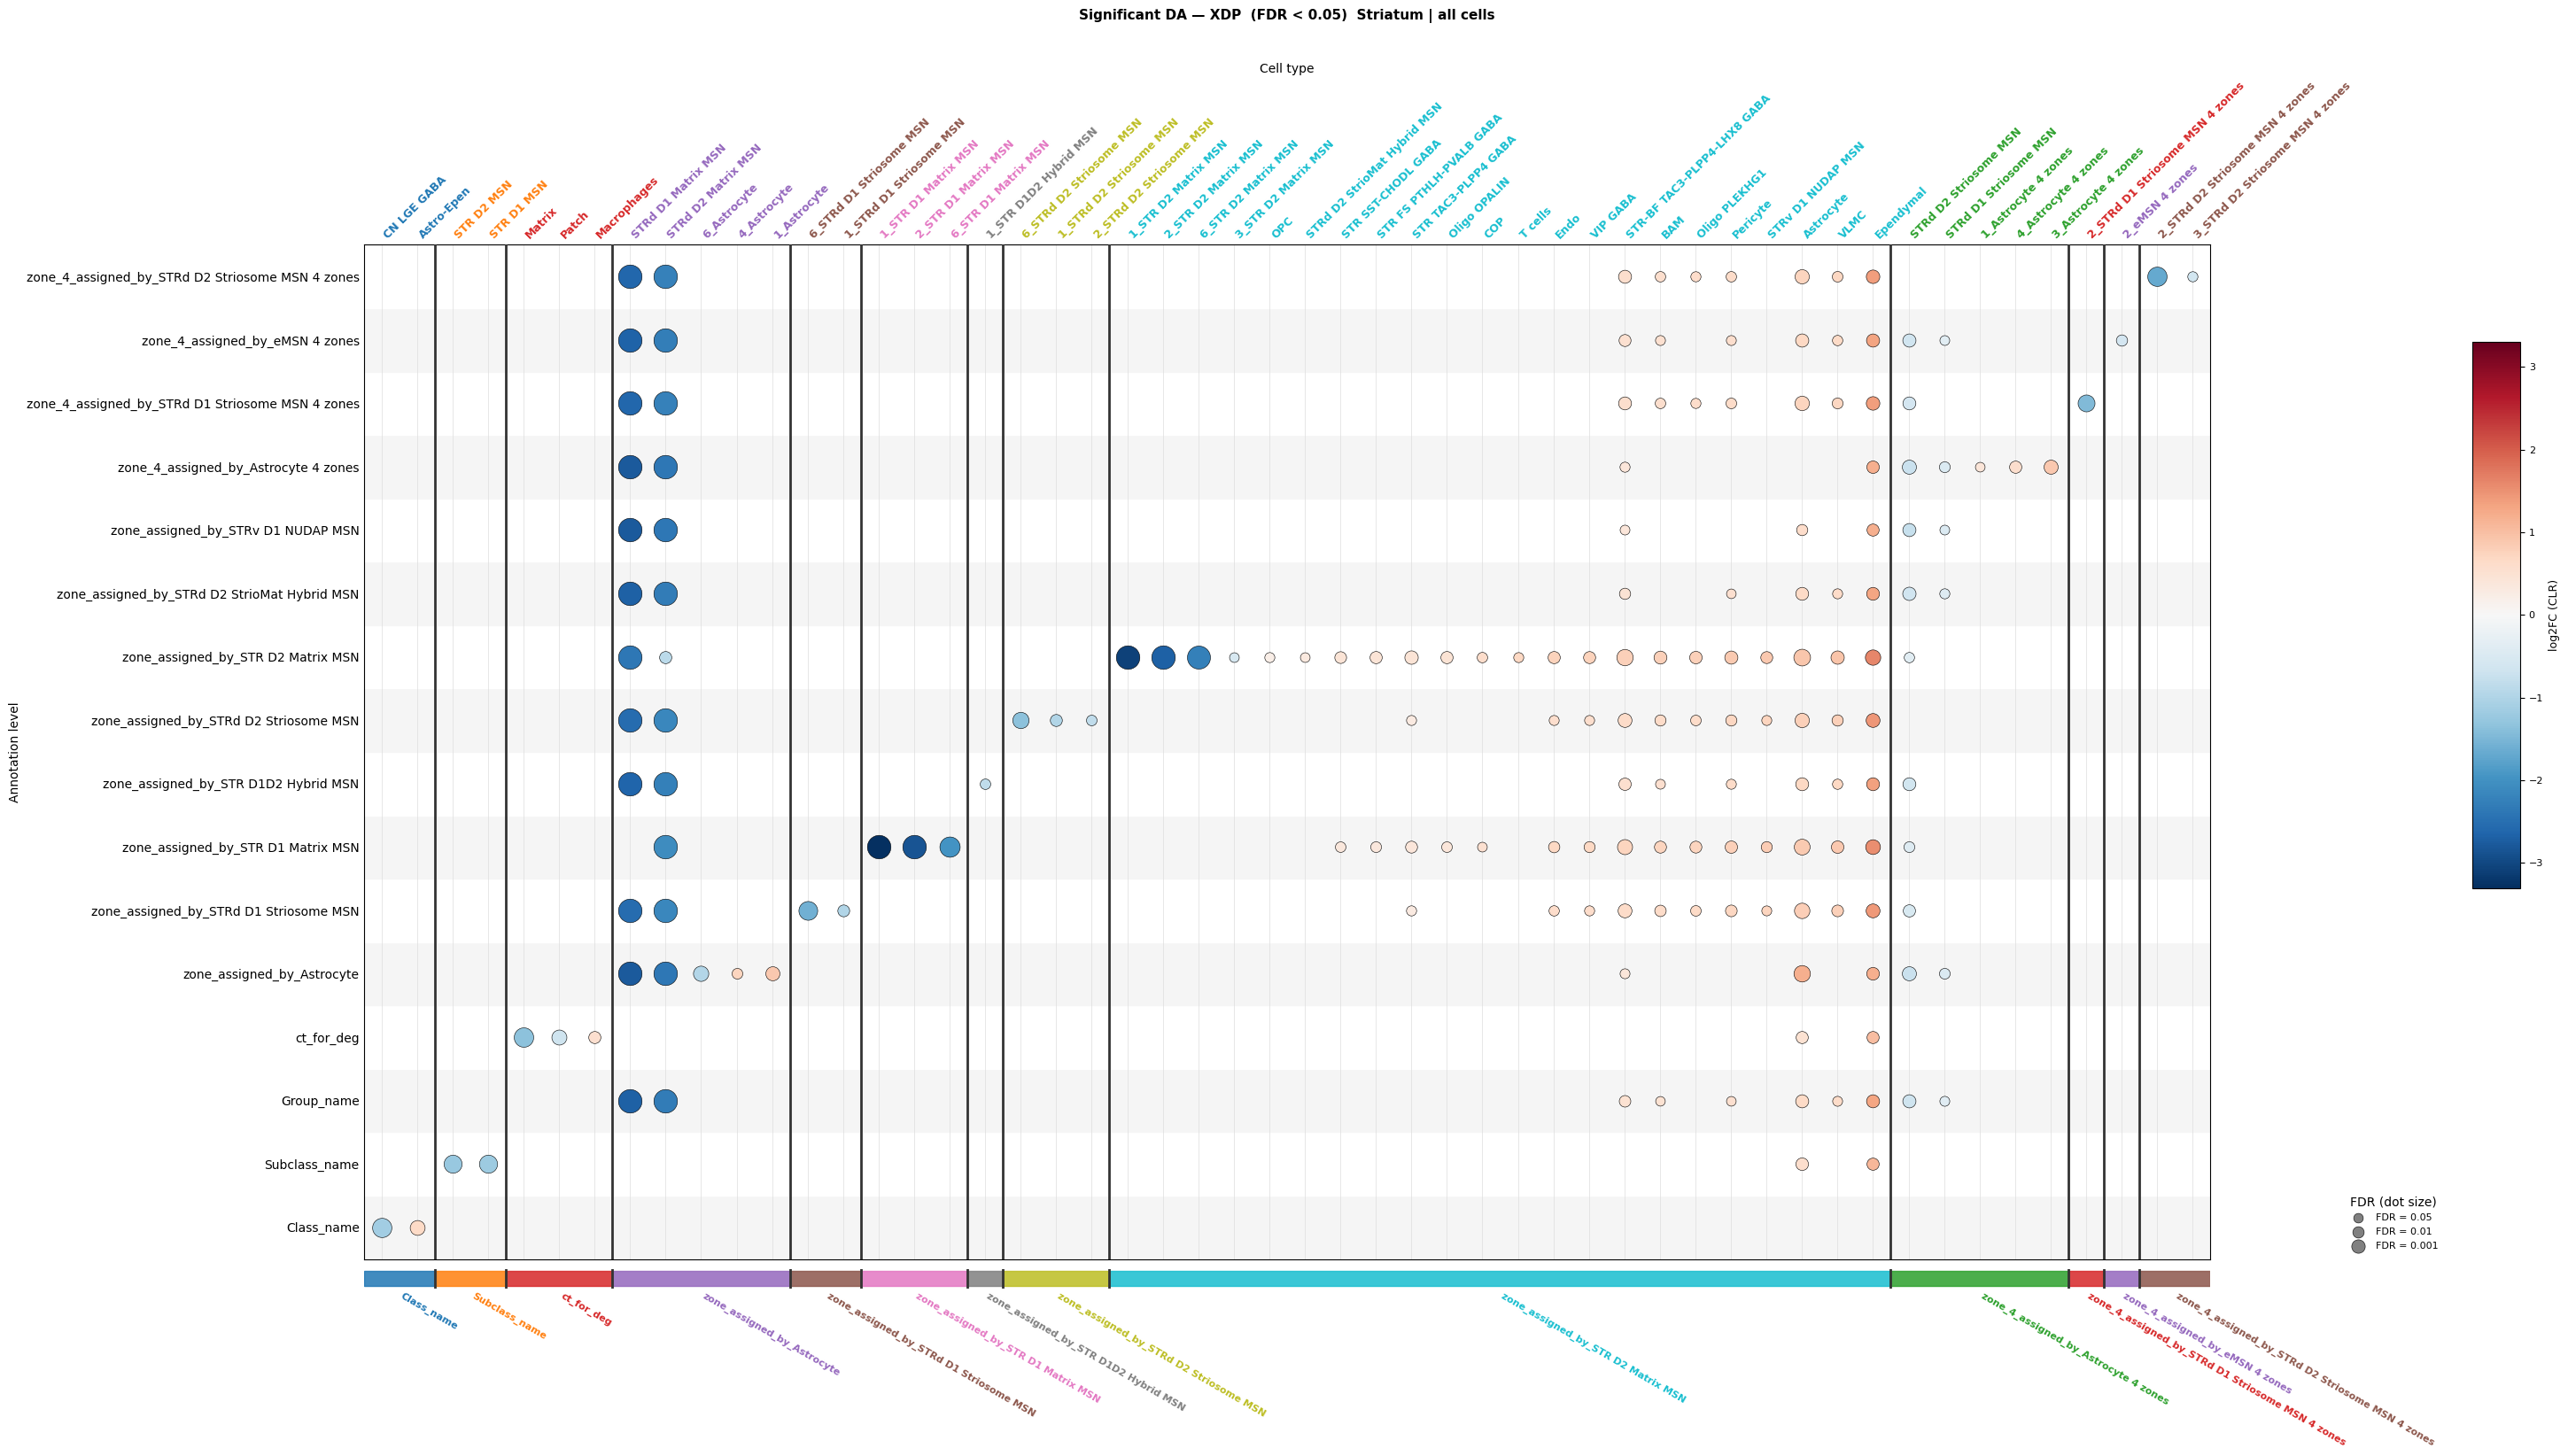

,logFC,AveExpr,t,P.Value,adj.P.Val,B,cell_type,coefficient,tissue,annotation,-log10FDR
0,0.510144,2.433028,3.510240,1.027079e-03,4.704297e-03,-1.271725,Astrocyte,conditionXDP,Striatum,ct_for_deg,2.327505
2,1.025261,-0.904908,3.462838,1.180638e-03,4.704297e-03,-1.586958,Ependymal,conditionXDP,Striatum,ct_for_deg,2.327505
5,0.548945,-0.792859,3.387628,1.470093e-03,4.704297e-03,-1.644347,Macrophages,conditionXDP,Striatum,ct_for_deg,2.327505
6,-1.345887,2.115908,-6.920200,1.312485e-08,2.099976e-07,9.536214,Matrix,conditionXDP,Striatum,ct_for_deg,6.677786
11,-0.685902,0.377530,-4.784326,1.866098e-05,1.492879e-04,2.564014,Patch,conditionXDP,Striatum,ct_for_deg,3.825975
...,...,...,...,...,...,...,...,...,...,...,...
439,0.641397,-1.074004,2.874165,6.195996e-03,2.307216e-02,-3.375296,Pericyte,conditionXDP,Striatum,zone_4_assigned_by_STRd D2 Striosome MSN 4 zones,1.636912
444,0.581731,-1.432916,3.902916,3.193607e-04,1.650030e-03,-0.556281,STR-BF TAC3-PLPP4-LHX8 GABA,conditionXDP,Striatum,zone_4_assigned_by_STRd D2 Striosome MSN 4 zones,2.782508
445,-2.615025,0.612515,-10.130477,4.036925e-13,6.257234e-12,19.542840,STRd D1 Matrix MSN,conditionXDP,Striatum,zone_4_assigned_by_STRd D2 Striosome MSN 4 zones,10.000000
447,-2.218731,0.868766,-11.553580,5.681144e-15,1.761155e-13,23.841201,STRd D2 Matrix MSN,conditionXDP,Striatum,zone_4_assigned_by_STRd D2 Striosome MSN 4 zones,10.000000


In [69]:
# ── call it ──
plot_significant_summary(
    "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/all_cells/merged_results.csv",
    contrast_stim=CONTRAST_STIM,
    label=f"{TISSUE} | all cells",
)

In [70]:
plot_significant_summary(
    "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/crumblr/Striatum/only_zone/all_results.csv",
    contrast_stim=CONTRAST_STIM,
    label=f"{TISSUE} | all cells",
)

KeyError: 'annotation'